TP: Causality - Causal Reasoning and Estimation
===============================================

Please send me your `main.ipynb` by the end of the day at [simon.ferreira@sorbonne-universite.fr](mailto:simon.ferreira@sorbonne-universite.fr).

**DO NOT FORGET TO WRITE YOUR NAME BELOW:**

Name: Issa KA 

Grading:
--------
Do not overly worry about grading. First focus on questions 1-6. If and only if you have time, look into either questions 7-9 or question 10 or question 11. 

Versions:
---------
* `Python 3.10.12` (However, it should work fine with reasonably older versions)
* All package requirements can be found in the `requirements.txt` file.

In [27]:
!pip install zepid==0.9.1
!pip install more-itertools==10.6.0
!pip install --upgrade networkx


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from zepid.causal.doublyrobust import TMLE
from itertools import combinations, chain
def allsubsets(s:set) -> list:
    return list(chain(*[combinations(s, n) for n in range(len(s)+1)]))

In [39]:
df = pd.read_csv('linear_dataframe.csv')
df.head()

,Z,V,U,W,X,M,Y
0,0.304717,-0.059283,-0.451951,1.202782,0.497559,-0.314260,0.489665
1,-1.039984,-0.729287,-0.665878,0.118848,-0.264818,-0.831498,-0.910729
2,0.750451,-0.414473,0.434010,1.642838,0.781148,-0.076057,1.597290
3,0.940565,0.633910,0.251854,-1.053383,3.278992,2.060179,2.192018
4,-1.951035,0.002993,-1.404792,-0.263025,-0.266566,-0.756279,-4.055898


Question 0:
----------
Using the `allsubsets` function and linear regression to compute the estimated effect of X on Y when adjusting on every possible sets of covariates.
Plot a histogram of the estimated effects.
What do you notice?

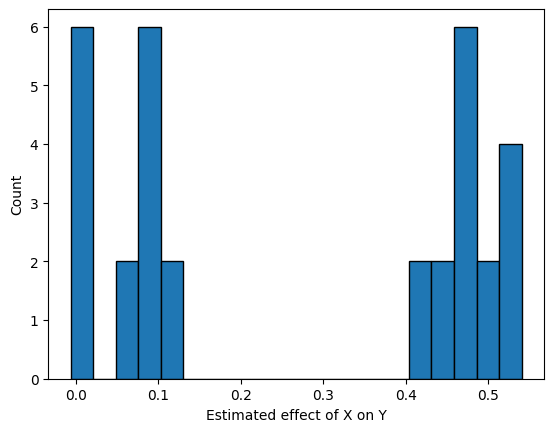

In [40]:
covariates = set(df.columns) - {'X', 'Y'} # on considère que les covariables sont toutes les variables sauf X et Y
subsets = allsubsets(covariates)

effects = []
labels = []

for subset in subsets:
    features = ['X'] + list(subset)
    X_data = df[features].values
    y_data = df['Y'].values
    
    reg = LinearRegression()
    reg.fit(X_data, y_data)

    beta_X = reg.coef_[0] # premier coefficient correspond à X
    effects.append(beta_X)
    labels.append(subset)

plt.hist(effects, bins=20, edgecolor='black')
plt.xlabel('Estimated effect of X on Y')
plt.ylabel('Count')
plt.show()



On remarque que l'effet estimé de X sur Y varie énormément en fonction du set d'ajustement. 

Certains sets bloquent surement des confounding paths ce qui donne une estimation plus correcte tandis que d'autre ajoutent du biais en conditionnant sur des mediators ou colliders. 

Ca montre que l'on peut pas estimer l'effet causal en se basant sur des ajustements abritraires et donc qu'il est nécessaire d'utiliser les hypothèses de structures causales i.e DAGs. 

Question 1:
----------

Using the function `nx.is_d_separator` to implement a function verifying if a set of variables is a valid backdoor set to identify the effect of a treatment on an outcome in a DAG.

j'ai recodé is_d_separator puisque j'avais des problèmes de versions networkx et n'arrivait pas à l'utiliser. 

In [ ]:
def is_d_separated(G: nx.DiGraph, x: str, y: str, Z: set) -> bool:
    undirected = G.to_undirected()
    
    for path in nx.all_simple_paths(undirected, x, y):
        blocked = False
        # On parcourt les noeuds intermédiaires du chemin
        for i in range(1, len(path) - 1):
            prev, node, nxt = path[i-1], path[i], path[i+1]
            # Vérifier si c'est un collider : prev → node ← nxt
            is_collider = G.has_edge(prev, node) and G.has_edge(nxt, node)
            
            if is_collider:
                # Collider : bloqué sauf si node ou un de ses descendants est dans Z
                descendants_and_self = nx.descendants(G, node) | {node}
                if not (descendants_and_self & Z):
                    blocked = True
                    break
            else:
                # Chaîne ou fork 
                if node in Z:
                    blocked = True
                    break
        
        if not blocked:
            return False  
    
    return True  # Tous les chemins sont bloqués

In [41]:
def is_backdoor_set(G: nx.DiGraph, treatment: str, outcome: str, backdoor_set: set) -> bool:
    # Condition 1 : aucun élément du backdoor set n'est un descendant du traitement
    descendants_of_treatment = nx.descendants(G, treatment)
    if backdoor_set & descendants_of_treatment:
        return False
    
    # Condition 2 : le backdoor set d-sépare treatment et outcome 
    # dans le graphe où on a retiré les arêtes sortantes du traitement
    G_modified = G.copy()
    edges_to_remove = list(G_modified.out_edges(treatment))
    G_modified.remove_edges_from(edges_to_remove)
    
    return is_d_separated(G_modified, treatment, outcome, backdoor_set)

Question 2:
----------
Using the `is_backdoor_set` function implement a function to find *every* valid backdoor set to identify the effect of a treatment on an outcome in a DAG. You can use the function `allsubsets` defined above.

In [42]:
def every_backdoor_set(G: nx.DiGraph, treatment: str, outcome: str) -> list:
    possible_vars = set(G.nodes()) - {treatment, outcome}
    subsets = allsubsets(possible_vars)
    
    valid_sets = []
    for subset in subsets:
        if is_backdoor_set(G, treatment, outcome, set(subset)):
            valid_sets.append(set(subset))
    
    return valid_sets

Question 3:
----------
Use the `every_backdoor_set` function to find every valid backdoor set to identify the effect of X on Y in the following DAG.

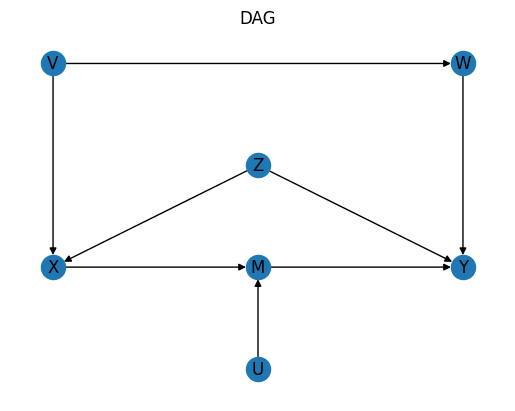

In [43]:
DAG = nx.DiGraph()
DAG.add_edges_from([('U','M'),('V','X'),('Z','X'),('X','M'),('V','W'),('Z','Y'),('M','Y'),('W','Y')])
pos = {'U':(1,0), 'X':(0,1), 'V':(0,3), 'M':(1,1), 'Y':(2,1), 'Z':(1,2), 'W':(2,3)}
ax = plt.gca()
ax.set_title('DAG')
nx.draw(DAG, pos=pos, with_labels=True, ax=ax)

In [44]:
valid_sets = every_backdoor_set(DAG, 'X', 'Y')
print(f"Nombre de backdoor sets valides : {len(valid_sets)}\n")
for s in valid_sets:
    print(f"  {s if s else '∅ (ensemble vide)'}")

Nombre de backdoor sets valides : 6

  {'W', 'Z'}
  {'V', 'Z'}
  {'W', 'U', 'Z'}
  {'W', 'V', 'Z'}
  {'U', 'V', 'Z'}
  {'W', 'U', 'V', 'Z'}


Question 4:
----------

Use a previously found valid adjustment set to estimate the effect of X on Y from the `linear_dataframe.csv` using a linear regression.

In [64]:
df = pd.read_csv('linear_dataframe.csv')
df.head()

,Z,V,U,W,X,M,Y
0,0.304717,-0.059283,-0.451951,1.202782,0.497559,-0.314260,0.489665
1,-1.039984,-0.729287,-0.665878,0.118848,-0.264818,-0.831498,-0.910729
2,0.750451,-0.414473,0.434010,1.642838,0.781148,-0.076057,1.597290
3,0.940565,0.633910,0.251854,-1.053383,3.278992,2.060179,2.192018
4,-1.951035,0.002993,-1.404792,-0.263025,-0.266566,-0.756279,-4.055898


In [67]:
for adj_set in valid_sets:
    features = ['X'] + list(adj_set)
    print(features)
    X_data = df[features].values
    y_data = df['Y'].values
    
    reg = LinearRegression()
    reg.fit(X_data, y_data)
    
    beta_X = reg.coef_[0]
    print(f"Ajustement sur {adj_set}, effet estimé de X sur Y : {beta_X:.4f}")



['X', 'W', 'Z']
Ajustement sur {'W', 'Z'}, effet estimé de X sur Y : 0.4309
['X', 'V', 'Z']
Ajustement sur {'V', 'Z'}, effet estimé de X sur Y : 0.4613
['X', 'W', 'U', 'Z']
Ajustement sur {'W', 'U', 'Z'}, effet estimé de X sur Y : 0.4176
['X', 'W', 'V', 'Z']
Ajustement sur {'W', 'V', 'Z'}, effet estimé de X sur Y : 0.4590
['X', 'U', 'V', 'Z']
Ajustement sur {'U', 'V', 'Z'}, effet estimé de X sur Y : 0.4390
['X', 'W', 'U', 'V', 'Z']
Ajustement sur {'W', 'U', 'V', 'Z'}, effet estimé de X sur Y : 0.4375


Question 5:
-----------
Use a previously found valid adjustment set to estimate the effect of X on Y from the `binary_treatment_fataframe.csv` using the TMLE method with default models.

The ZEPID implementation of TMLE requires a binary treatment.

In [71]:
df = pd.read_csv('binary_treatment_dataframe.csv')
df.head()

,Z,V,U,W,X,M,Y
0,0.304717,-0.059283,-0.451951,1.202782,0,-0.538162,0.281436
1,-1.039984,-0.729287,-0.665878,0.118848,1,-0.262330,-0.381403
2,0.750451,-0.414473,0.434010,1.642838,1,0.022426,1.688879
3,0.940565,0.633910,0.251854,-1.053383,1,1.034633,1.238260
4,-1.951035,0.002993,-1.404792,-0.263025,0,-0.636325,-3.944340


In [ ]:
# Question 5 : TMLE avec modèles par défaut (logistic regression + linear regression)
adj_set = {'Z', 'W'}  # un valid backdoor set
confounders = list(adj_set)

tmle = TMLE(df, exposure='X', outcome='Y')

tmle.exposure_model(' + '.join(confounders))
tmle.outcome_model(' + '.join(confounders))

tmle.fit()

print(f"Adjustment set: {adj_set}")
print(f"ATE (Average Treatment Effect): {tmle.average_treatment_effect:.4f}")
print(f"95% CI: ({tmle.average_treatment_effect_ci[0]:.4f}, {tmle.average_treatment_effect_ci[1]:.4f})")
tmle.summary()

Propensity Score Model
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      X   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -623.88
Date:                Thu, 19 Feb 2026   Deviance:                       1247.8
Time:                        11:09:10   Pearson chi2:                     997.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1294
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0312      0.

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/zepid/causal/doublyrobust/TMLE.py:338: UserWarning: It looks like 'X' is not included in the outcome model.
  warnings.warn("It looks like '" + self.exposure + "' is not included in the outcome model.")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/zepid/causal/doublyrobust/TMLE.py:442: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Qstar1 = logistic.cdf(np.log(probability_to_odds(self.QA1W)) + self._epsilon[0] / self.g1W_total)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/zepid/causal/doublyrobust/TMLE.py:443: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consisten

Question 6:
----------
Use a previously found valid adjustment set to estimate the effect of X on Y from the `binary_treatment_fataframe.csv` using the TMLE method with non-default models. For example, use random forest models.

In [49]:
df = pd.read_csv('binary_treatment_dataframe.csv')
df.head()

,Z,V,U,W,X,M,Y
0,0.304717,-0.059283,-0.451951,1.202782,0,-0.538162,0.281436
1,-1.039984,-0.729287,-0.665878,0.118848,1,-0.262330,-0.381403
2,0.750451,-0.414473,0.434010,1.642838,1,0.022426,1.688879
3,0.940565,0.633910,0.251854,-1.053383,1,1.034633,1.238260
4,-1.951035,0.002993,-1.404792,-0.263025,0,-0.636325,-3.944340


In [ ]:
# Question 6 : TMLE avec modèles non-default (Random Forest)
adj_set = {'Z', 'W'}  # un valid backdoor set
confounders = list(adj_set)

tmle = TMLE(df, exposure='X', outcome='Y')

tmle.exposure_model(' + '.join(confounders), custom_model=RandomForestClassifier(n_estimators=200, random_state=42))
tmle.outcome_model(' + '.join(confounders), custom_model=RandomForestRegressor(n_estimators=200, random_state=42))

tmle.fit()

print(f"Adjustment set: {adj_set}")
print(f"ATE (Average Treatment Effect): {tmle.average_treatment_effect:.4f}")
print(f"95% CI: ({tmle.average_treatment_effect_ci[0]:.4f}, {tmle.average_treatment_effect_ci[1]:.4f})")
tmle.summary()

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/zepid/causal/doublyrobust/TMLE.py:338: UserWarning: It looks like 'X' is not included in the outcome model.
  warnings.warn("It looks like '" + self.exposure + "' is not included in the outcome model.")


Adjustment set: {'W', 'Z'}
ATE (Average Treatment Effect): 1.0125
95% CI: (0.9404, 1.0846)
                Targeted Maximum Likelihood Estimator                 
Treatment:        X               No. Observations:     1000                
Outcome:          Y               No. Missing Outcome:  0                   
g-Model:          User-specified  Missing Model:        None                
Q-Model:          User-specified 
Average Treatment Effect:  1.013
95.0% two-sided CI: (0.94 , 1.085)


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/zepid/causal/doublyrobust/TMLE.py:442: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Qstar1 = logistic.cdf(np.log(probability_to_odds(self.QA1W)) + self._epsilon[0] / self.g1W_total)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/zepid/causal/doublyrobust/TMLE.py:442: RuntimeWarning: divide by zero encountered in divide
  Qstar1 = logistic.cdf(np.log(probability_to_odds(self.QA1W)) + self._epsilon[0] / self.g1W_total)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/zepid/causal/doublyrobust/TMLE.py:443: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Data

Question 7:
----------
Repeat questions 1 and 2 in the case of a CPDAG.
You can use theorem 3.7 of [A GENERALIZED BACK-DOOR CRITERION" by Maathuis and Colombo](https://projecteuclid.org/journalArticle/Download?urlId=10.1214%2F14-AOS1295).

In [51]:
def is_backdoor_set_CPDAG(G: nx.DiGraph, treatment: str, outcome: str, backdoor_set: set) -> bool:
    #TODO
    pass
def every_backdoor_set_CPDAG(G: nx.DiGraph, treatment: str, outcome: str) -> set:
    #TODO
    pass

Question 8:
----------
Use the `every_backdoor_set_CPDAG` function to find every valid backdoor set to identify the effect of X on Y in the following CPDAG.



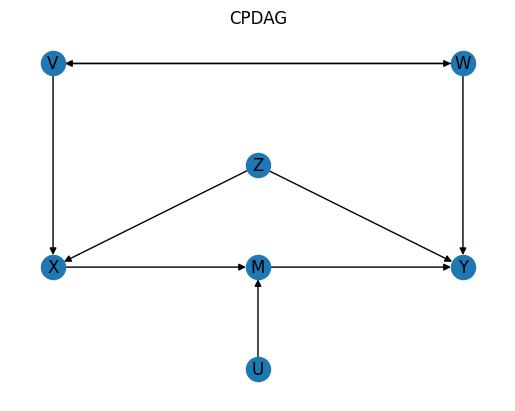

In [52]:
CPDAG = nx.DiGraph()
CPDAG.add_edges_from([('U','M'),('V','X'),('Z','X'),('X','M'),('V','W'),('W','V'),('Z','Y'),('M','Y'),('W','Y')])
pos = {'U':(1,0), 'X':(0,1), 'V':(0,3), 'M':(1,1), 'Y':(2,1), 'Z':(1,2), 'W':(2,3)}
ax = plt.gca()
ax.set_title('CPDAG')
nx.draw(CPDAG, pos=pos, with_labels=True, ax=ax)


In [53]:
#TODO

Question 9:
-----------
Compare with the results of questions 3.

#TODO

Question 10:
-----------------
Suppose you forgot to measure the variable 'Z' as is shown in the following graph and as provided in the following dataframe.

Is it still possible to identify the effect of X on Y using the backdoor criterion?
* If yes, do it and compare with previous results.
* If not, is it possible to identify the effect if X on Y using another criterion or other identification methods?
    - If yes, do it and compare with previous results.
    - If not, explain why not.

,V,U,W,X,M,Y
0,-0.059283,-0.451951,1.202782,0.497559,-0.314260,0.489665
1,-0.729287,-0.665878,0.118848,-0.264818,-0.831498,-0.910729
2,-0.414473,0.434010,1.642838,0.781148,-0.076057,1.597290
3,0.633910,0.251854,-1.053383,3.278992,2.060179,2.192018
4,0.002993,-1.404792,-0.263025,-0.266566,-0.756279,-4.055898


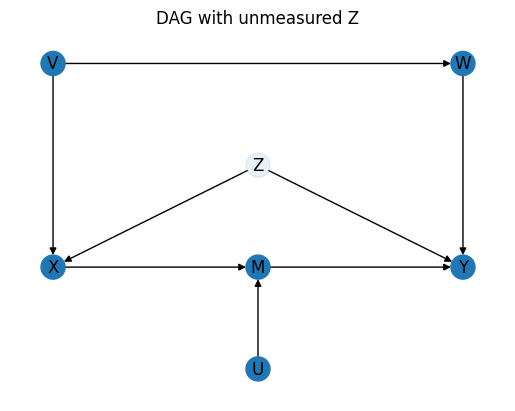

In [54]:
df = pd.read_csv('linear_dataframe_with_hidden_Z.csv')
pos = {'U':(1,0), 'X':(0,1), 'V':(0,3), 'M':(1,1), 'Y':(2,1), 'Z':(1,2), 'W':(2,3)}
ax = plt.gca()
ax.set_title('DAG with unmeasured Z')
node_color=[(0.12,0.47,0.71,.1) if n=='Z' else (0.12,0.47,0.71,1.) for n in DAG.nodes()]
nx.draw(DAG, pos=pos, node_color=node_color, with_labels=True, ax=ax)
df.head()

In [55]:
#TODO

Question 11:
---------------
For every estimator used previously, and for every valid backdoor set, estimate the effect of X on Y multiple times with each time a different sub samples of the dataframe. Which backdoor set seems best?

In [56]:
#TODO